# forcing timeseries

In [1]:
using JLD2
using Plots

gr()
default(size=(1100, 400), linewidth=1.5)

const ROOT = normpath(joinpath(@__DIR__, ".."))
const SITES = ["lat30lon-50", "lat-25lon-10", "lat-45lon80", "lat0lon-140", "lat30lon-150", "lat40lon-25"]

include(joinpath(ROOT, "src/forcing/load_era5_v2.jl"))
include(joinpath(ROOT, "src/forcing/compute_surface_fluxes_v2.jl"))
using .LoadERA5v2: load_era5_point_v2
using .ComputeSurfaceFluxesV2: wind_stress, net_surface_heat_flux_v2

In [2]:
function plot_forcing(site::String; N_hours=30*24)
    qt_f = joinpath(ROOT, "output/era5/ml_forced_30day_v2_qt_$(site).jld2")
    era_f = joinpath(ROOT, "data/NewEra5/$(site).nc")
    isfile(qt_f) || (println("no sim at $site"); return nothing)

    sim = JLD2.load(qt_f)
    era = load_era5_point_v2(era_f)

    N = min(N_hours, length(era.time))
    hrs = (0:N-1) ./ 24

    # bulk formula targets computed fresh from the same era5
    τx_bulk, τy_bulk = wind_stress(era.u10[1:N], era.v10[1:N])
    QT_bulk = net_surface_heat_flux_v2(
        era.t2m[1:N], era.sst[1:N], era.u10[1:N], era.v10[1:N],
        era.ssrd[1:N], era.strd[1:N], era.d2m[1:N])

    τx_ml = sim["τx"][1:N]
    τy_ml = sim["τy"][1:N]
    QT_ml = sim["QT"][1:N] .* 1027.0 .* 3985.0   # stored in K·m/s, show as W/m²

    p1 = plot(hrs, τx_bulk, label="bulk", color=:green, xlabel="Day", ylabel="τx (N/m²)", title="$site — τx")
    plot!(p1, hrs, τx_ml, label="v2 MLP", color=:red, alpha=0.7)
    p2 = plot(hrs, τy_bulk, label="bulk", color=:green, xlabel="Day", ylabel="τy (N/m²)", title="$site — τy")
    plot!(p2, hrs, τy_ml, label="v2 MLP", color=:red, alpha=0.7)
    p3 = plot(hrs, QT_bulk, label="bulk", color=:green, xlabel="Day", ylabel="QT (W/m²)", title="$site — QT")
    plot!(p3, hrs, QT_ml, label="v2 MLP", color=:red, alpha=0.7)

    plot(p1, p2, p3, layout=(3, 1), size=(1100, 900))
end

plot_forcing (generic function with 1 method)

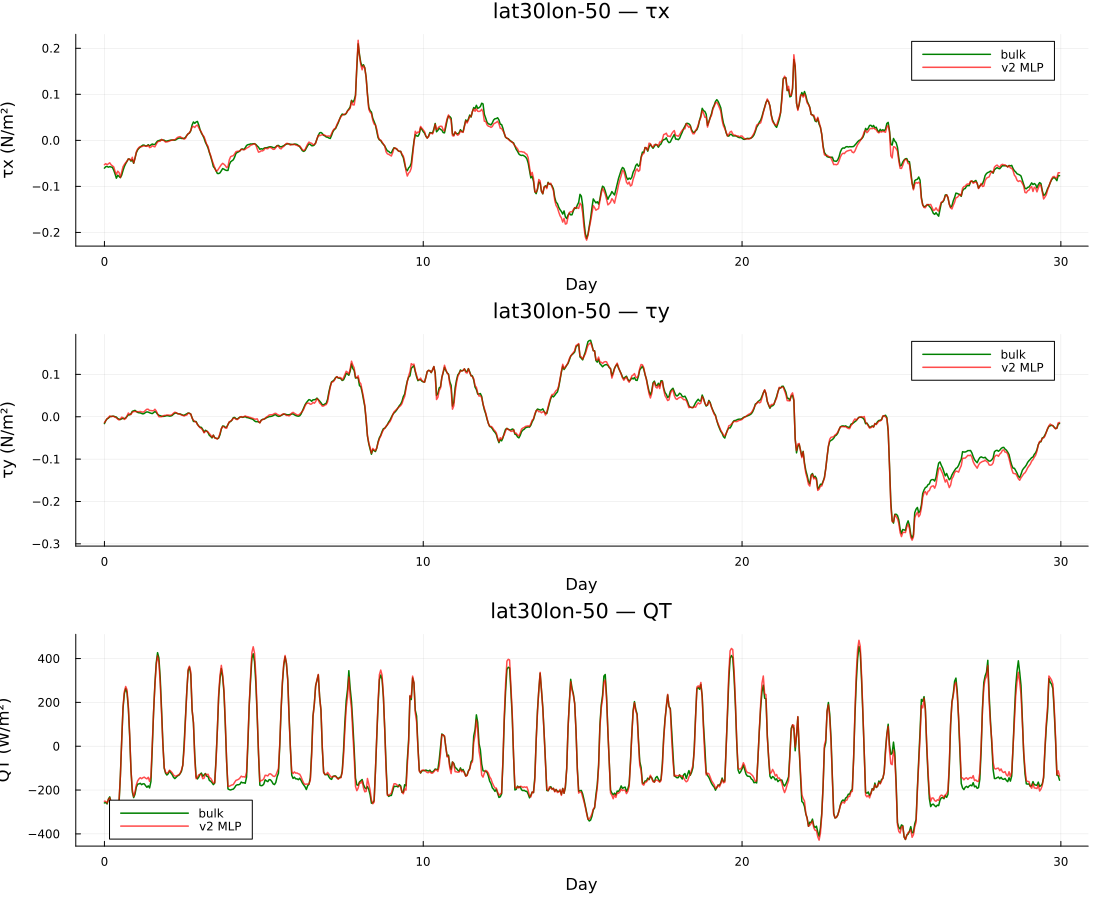

In [3]:
plot_forcing("lat30lon-50")

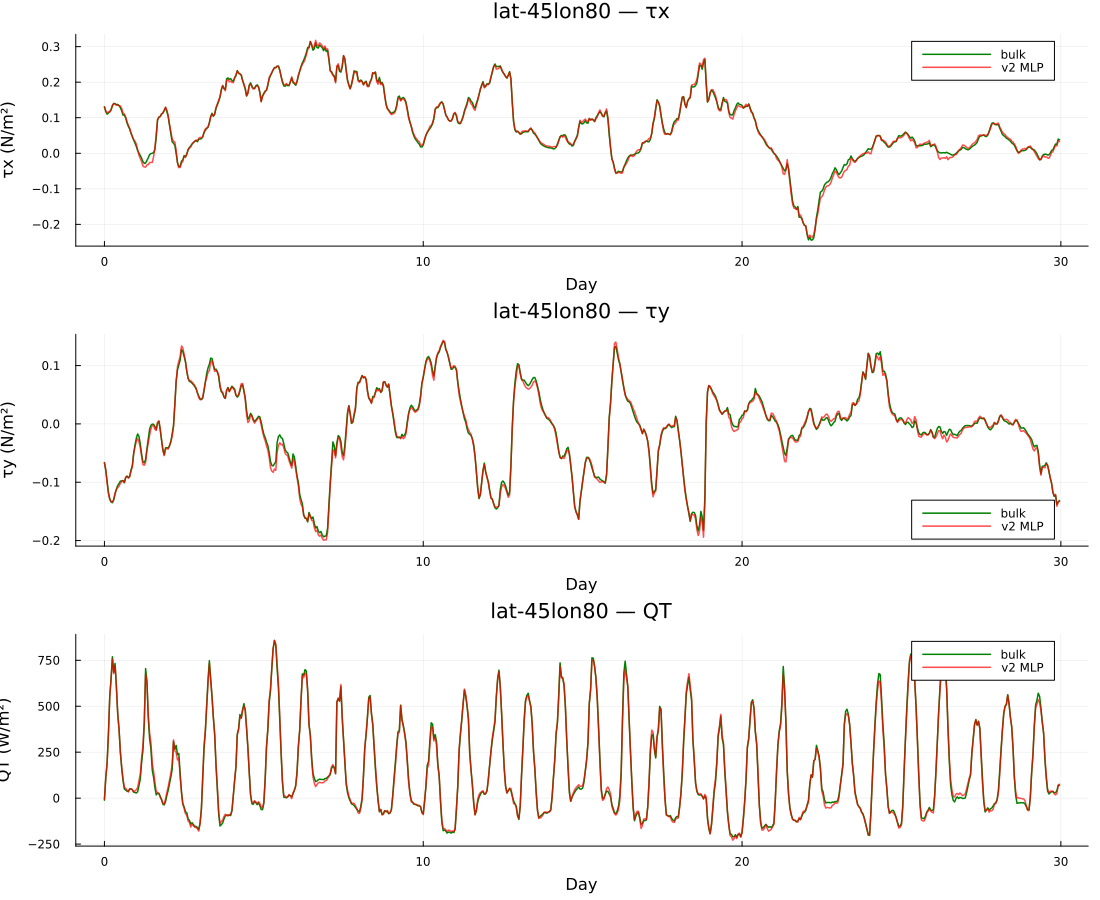

In [4]:
# stormy southern-ocean site
plot_forcing("lat-45lon80")

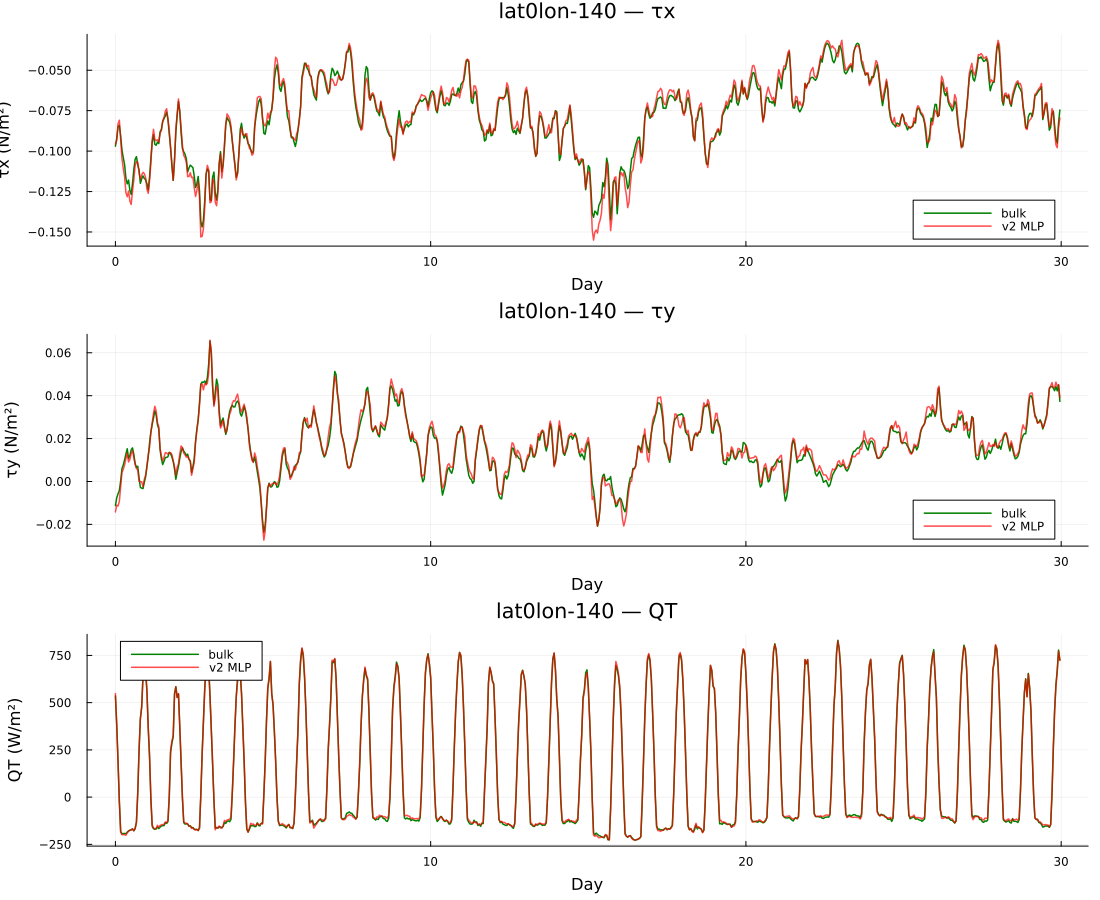

In [5]:
# hard tropical site
plot_forcing("lat0lon-140")

## bulk vs MLP RMSE over the sim window

In [6]:
using Statistics, Printf

println(rpad("site", 14), " | ", rpad("τx RMSE", 10), rpad("τy RMSE", 10), "QT RMSE (W/m²)")
println("-" ^ 55)
for site in SITES
    qt_f = joinpath(ROOT, "output/era5/ml_forced_30day_v2_qt_$(site).jld2")
    era_f = joinpath(ROOT, "data/NewEra5/$(site).nc")
    (isfile(qt_f) && isfile(era_f)) || continue
    sim = JLD2.load(qt_f)
    era = load_era5_point_v2(era_f)
    N = min(30*24, length(era.time))
    τx_b, τy_b = wind_stress(era.u10[1:N], era.v10[1:N])
    QT_b = net_surface_heat_flux_v2(era.t2m[1:N], era.sst[1:N], era.u10[1:N], era.v10[1:N], era.ssrd[1:N], era.strd[1:N], era.d2m[1:N])
    QT_ml = sim["QT"][1:N] .* 1027.0 .* 3985.0
    @printf("%-14s | %-10.4f %-10.4f %.1f\n", site,
            sqrt(mean((sim["τx"][1:N] .- τx_b).^2)),
            sqrt(mean((sim["τy"][1:N] .- τy_b).^2)),
            sqrt(mean((QT_ml .- QT_b).^2)))
end

site           | τx RMSE   τy RMSE   QT RMSE (W/m²)
-------------------------------------------------------
lat30lon-50    | 0.0065     0.0055     17.9
lat-25lon-10   | 0.0048     0.0037     13.0
lat-45lon80    | 0.0055     0.0044     13.2
lat0lon-140    | 0.0033     0.0020     7.5
lat30lon-150   | 0.0100     0.0046     16.1
lat40lon-25    | 0.0107     0.0069     39.7
